### 0. 데이터 로드 및 이벤트 로그 변환

In [10]:
import pandas as pd
from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter

# 1) CSV 로딩
df = pd.read_csv("mimicel_los_zone.csv")

# 2) 표준 컬럼 이름 설정
df = df.rename(columns={
    "stay_id": "case:concept:name",
    "activity": "concept:name",
    "timestamps": "time:timestamp"
})

# 3) timestamp 변환
df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], errors="coerce")

# 4) timestamp 처리 및 정렬
df = dataframe_utils.convert_timestamp_columns_in_df(df)
df = df.sort_values("time:timestamp")

# 5) PM4Py에 EventLog라고 명시적으로 알려줌
parameters = {
    log_converter.Variants.TO_EVENT_LOG.value.Parameters.CASE_ID_KEY: "case:concept:name"
}

log = log_converter.apply(df, variant=log_converter.Variants.TO_EVENT_LOG, parameters=parameters)

print("✔ mimicel_los_zone.csv → Event Log 변환 완료")
print("총 케이스 수:", len(log))

✔ mimicel_los_zone.csv → Event Log 변환 완료
총 케이스 수: 295485


### 1. Process Discovery

1-1. Alpha Miner

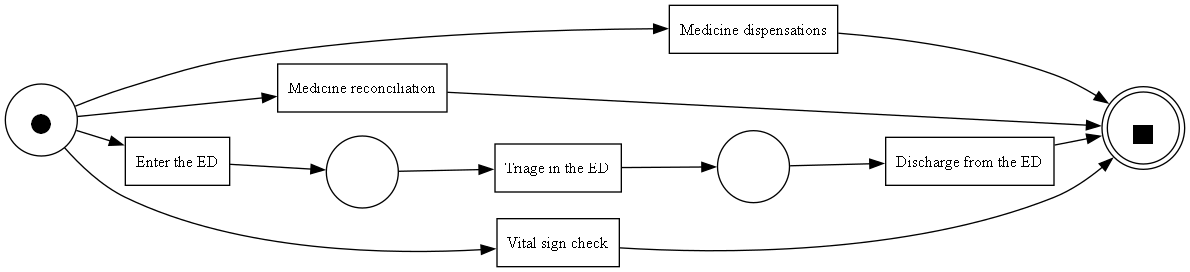

In [11]:
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.visualization.petri_net import visualizer as pn_visualizer

net_a, im_a, fm_a = alpha_miner.apply(log)
gviz = pn_visualizer.apply(net_a, im_a, fm_a)
pn_visualizer.view(gviz)

1-2. Heuristic Miner

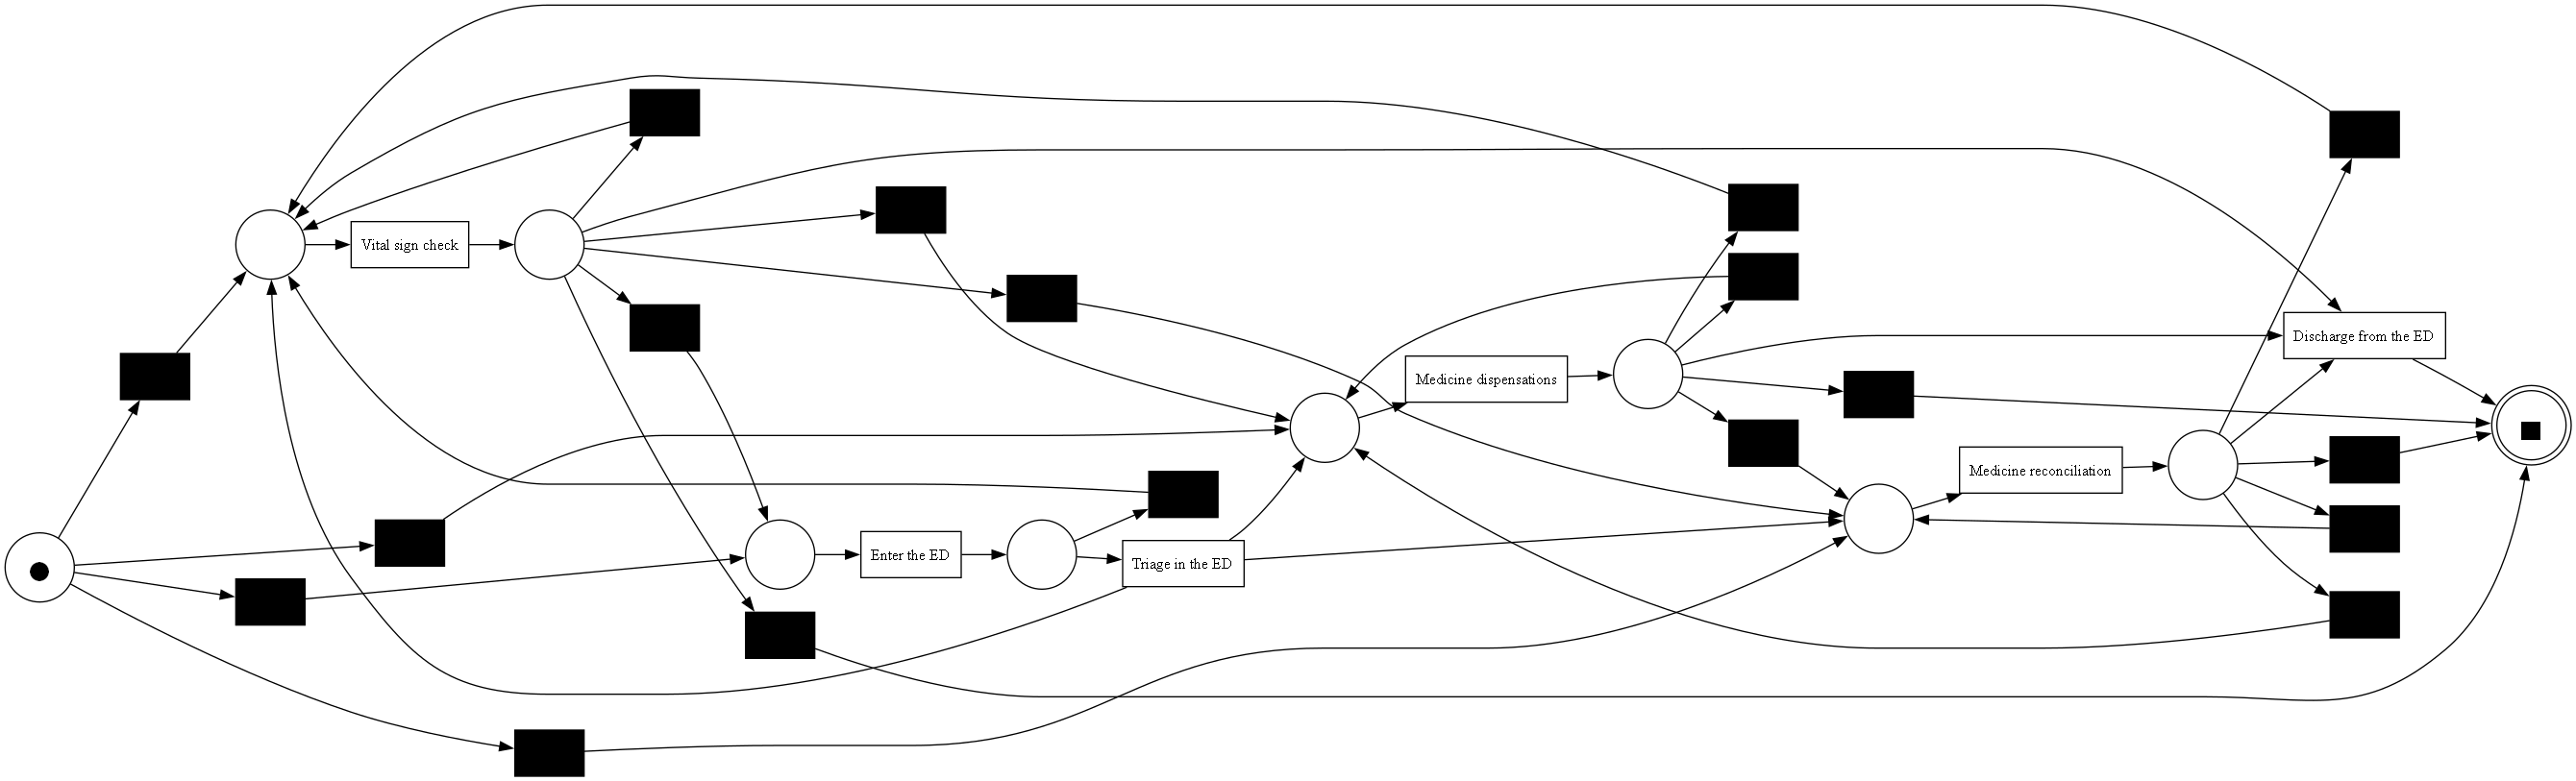

In [12]:
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner

heu_net = heuristics_miner.apply_heu(log)
net_h, im_h, fm_h = heuristics_miner.apply(log)
gviz = pn_visualizer.apply(net_h, im_h, fm_h)
pn_visualizer.view(gviz)

1-3. Inductive Miner

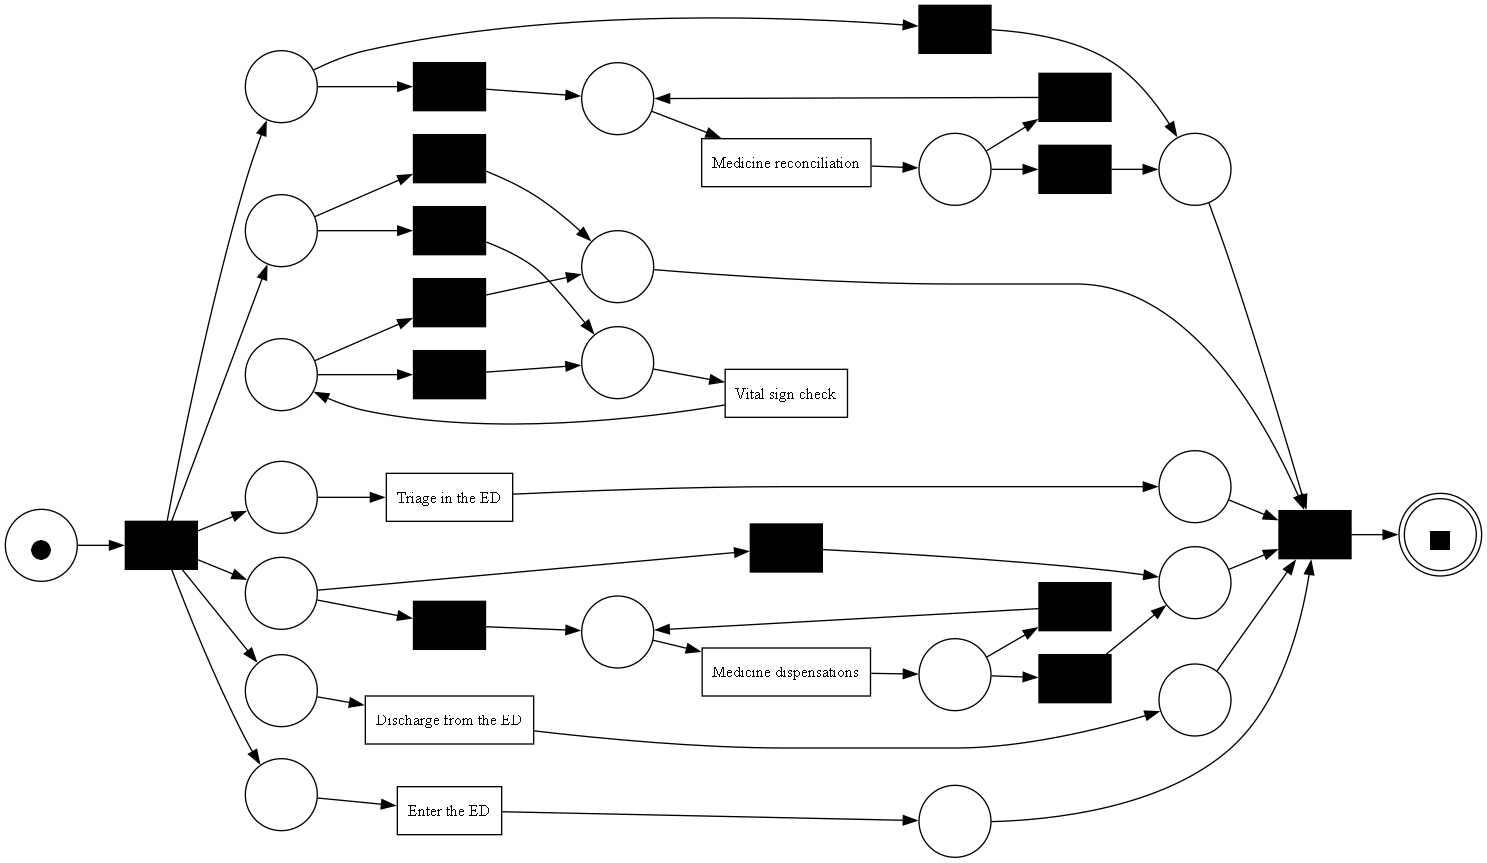

In [13]:
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.visualization.petri_net import visualizer as pn_visualizer

# 1) process tree 반환
ptree = inductive_miner.apply(log)

# 2) process tree → petri net 변환
net, im, fm = pt_converter.apply(ptree)

# 3) 시각화
gviz = pn_visualizer.apply(net, im, fm)
pn_visualizer.view(gviz)

### 2. Conformance Checking

2-1. Token Replay 기반 Fitness

In [13]:
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay

def token_replay_analysis(log, net, im, fm):
    """
    PM4PY 최신 버전(2.7+ 이상) 호환용 Token Replay 분석 함수.
    log_fitness + p/c/r/m 총합 + 평균 trace_fitness 반환.
    """
    replay_result = token_replay.apply(log, net, im, fm)
    
    total_trace_fitness = 0
    total_traces = len(replay_result)

    # p/c/r/m 총합
    total_missing = 0
    total_consumed = 0
    total_remaining = 0
    total_produced = 0

    for item in replay_result:
        total_trace_fitness += item["trace_fitness"]

        total_missing += item["missing_tokens"]
        total_consumed += item["consumed_tokens"]
        total_remaining += item["remaining_tokens"]
        total_produced += item["produced_tokens"]

    # log fitness = 단순 평균(trace_fitness)
    log_fitness = total_trace_fitness / total_traces

    return {
        "log_fitness": log_fitness,
        "avg_trace_fitness": log_fitness,
        "total_missing_tokens": total_missing,
        "total_consumed_tokens": total_consumed,
        "total_remaining_tokens": total_remaining,
        "total_produced_tokens": total_produced,
        "num_traces": total_traces
    }

alpha_res = token_replay_analysis(log, net_a, im_a, fm_a)
hm_res    = token_replay_analysis(log, net_h, im_h, fm_h)
im_res    = token_replay_analysis(log, net, im, fm)

print(alpha_res)
print(hm_res)
print(im_res)

replaying log with TBR, completed traces :: 100%|██████████| 107823/107823 [03:07<00:00, 574.22it/s]


{'log_fitness': 0.32615232911191855, 'avg_trace_fitness': 0.32615232911191855, 'total_missing_tokens': 4115003, 'total_consumed_tokens': 5296943, 'total_remaining_tokens': 4115003, 'total_produced_tokens': 5296943, 'num_traces': 295485}
{'log_fitness': 0.9179768213232666, 'avg_trace_fitness': 0.9179768213232666, 'total_missing_tokens': 486040, 'total_consumed_tokens': 9598525, 'total_remaining_tokens': 486040, 'total_produced_tokens': 9598525, 'num_traces': 295485}
{'log_fitness': 1.0, 'avg_trace_fitness': 1.0, 'total_missing_tokens': 0, 'total_consumed_tokens': 12366796, 'total_remaining_tokens': 0, 'total_produced_tokens': 12366796, 'num_traces': 295485}


2-2. Alignment 기반 Fitness

In [18]:
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments
from pm4py.statistics.variants.log import get as variants_module
import pandas as pd

# ---------------------------
# 0) Variant 빈도 계산 (필수)
# ---------------------------
variants = variants_module.get_variants(log)
# variants: {"A,B,C": [trace1, trace2, ...], ...}
variants_count = {k: len(v) for k, v in variants.items()}

# alignment 결과를 variant key로 변환
def alignment_to_key(case_result):
    return ",".join(step[0] for step in case_result["alignment"])


# ---------------------------
# 1) Trace-weighted Alignment 함수
# ---------------------------
def run_alignment_fixed(log, net, im, fm):
    aligned = alignments.apply(log, net, im, fm)

    total_traces = 0
    weighted_fitness_sum = 0
    log_moves = 0
    model_moves = 0
    sync_moves = 0

    for case_result in aligned:
        # 🔥 variant_occurrences 대신 우리가 직접 계산한 occ 사용
        key = alignment_to_key(case_result)
        occ = variants_count.get(key, 1)  # 혹시 매칭 실패하면 최소 1

        total_traces += occ
        weighted_fitness_sum += case_result["fitness"] * occ

        # move 계산
        for step in case_result["alignment"]:
            if step[0] == step[1]:
                sync_moves += occ
            elif step[0] == ">>":
                model_moves += occ
            elif step[1] == ">>":
                log_moves += occ

    return {
        "avg_fitness": weighted_fitness_sum / total_traces,
        "log_moves": log_moves,
        "model_moves": model_moves,
        "sync_moves": sync_moves,
        "num_traces": total_traces
    }


# ---------------------------
# 2) Miner별 실행
# ---------------------------
print("▶ Alpha Miner Alignment (Trace-weighted) 중…")
alpha_result = run_alignment_fixed(log, net_a, im_a, fm_a)

print("▶ Heuristic Miner Alignment (Trace-weighted) 중…")
heu_result = run_alignment_fixed(log, net_h, im_h, fm_h)

print("▶ Inductive Miner Alignment (Trace-weighted) 중…")
ind_result = run_alignment_fixed(log, net, im, fm)


# ---------------------------
# 3) 결과 출력
# ---------------------------
res_df = pd.DataFrame([
    ["Alpha Miner", alpha_result["avg_fitness"], alpha_result["log_moves"], alpha_result["model_moves"], alpha_result["sync_moves"]],
    ["Heuristic Miner", heu_result["avg_fitness"], heu_result["log_moves"], heu_result["model_moves"], heu_result["sync_moves"]],
    ["Inductive Miner", ind_result["avg_fitness"], ind_result["log_moves"], ind_result["model_moves"], ind_result["sync_moves"]],
], columns=["Miner", "Fitness", "Log Move", "Model Move", "Sync Move"])

print("\n========================")
print("      ALIGNMENT RESULT (Trace-level Corrected)")
print("========================")
print(res_df)

▶ Alpha Miner Alignment (Trace-weighted) 중…


aligning log, completed variants :: 100%|██████████| 107823/107823 [12:22<00:00, 145.21it/s] 


▶ Heuristic Miner Alignment (Trace-weighted) 중…


aligning log, completed variants :: 100%|██████████| 107823/107823 [1:40:36<00:00, 17.86it/s]  


▶ Inductive Miner Alignment (Trace-weighted) 중…


aligning log, completed variants :: 100%|██████████| 107823/107823 [1:36:52<00:00, 18.55it/s]  



      ALIGNMENT RESULT (Trace-level Corrected)
             Miner   Fitness  Log Move  Model Move  Sync Move
0      Alpha Miner  0.326152   4115003           0     886455
1  Heuristic Miner  0.910244     47333     3877162    4954125
2  Inductive Miner  1.000000         0     5592428    5001458
